# Tail-Centric Caching: AI-Powered Eviction for Wikimedia CDN
## Reducing Latency via Relaxed Belady with XGBoost

**Approach**: Train a lightweight XGBoost model to imitate relaxed Belady's eviction policy,
using a latency-aware scoring function. Evaluated against LRU and B-LRU baselines using:
- Per-percentile latency (P50, P75, P90, P95, P99)
- **Byte miss ratio** (the primary metric from the LRB paper)
- High-penalty object cache rate (are we caching the right objects?)

## Step 1: Load & Sample Data

In [90]:
import pandas as pd
import numpy as np
from collections import OrderedDict, deque
import warnings
import random
warnings.filterwarnings('ignore')

In [91]:
import os
from tqdm import tqdm

# === CONFIGURE YOUR PATH HERE ===
path_drive = "/content/drive/MyDrive/cache-u-00.tsv"
path_local  = "./cache-u-00.tsv"
path = path_drive if os.path.exists(path_drive) else path_local

CHUNK_SIZE = 500_000

def load_contiguous_chunk(filename, chunk_size, skip_rows=0):
    rows = []
    with open(filename, 'r', encoding='utf-8') as f:
        for i, line in tqdm(enumerate(f), total=skip_rows + chunk_size, desc="Loading"):
            if i < skip_rows:
                continue
            if i >= skip_rows + chunk_size:
                break
            try:
                parts = line.strip().split('\t')
                if len(parts) < 5:
                    continue
                rows.append({
                    'timestamp': int(parts[0]),
                    'hash': int(parts[1]),
                    'image_type': parts[2] if parts[2] else 'unknown',
                    'size': int(parts[3]),
                    'firstbyte': float(parts[4])
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows)

df = load_contiguous_chunk(path, CHUNK_SIZE)
df = df.dropna()
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = df['timestamp'].astype('int64')
df['hash']      = df['hash'].astype('int64')
df['size']      = df['size'].astype('int64')

print(f"\nLoaded {len(df):,} requests | {df['hash'].nunique():,} unique objects")
print(f"Timestamp range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(df[['timestamp','hash','image_type','size','firstbyte']].head())

Loading:   0%|          | 0/500000 [00:00<?, ?it/s]


Loaded 499,999 requests | 335,040 unique objects
Timestamp range: 0 → 288
   timestamp        hash image_type   size  firstbyte
0          0  1265875998       jpeg   4870   0.000171
1          0  1482473017       jpeg  10753   0.000207
2          0 -1678029809       jpeg  16578   0.000196
3          0  1556940108       jpeg  35953   0.000161
4          0    48281339        png    771   0.000206


## Step 2: Data Exploration

In [71]:
size_pcts = df['size'].quantile([0.50, 0.75, 0.90, 0.95, 0.99])
print("Object Size Distribution:")
for p, v in size_pcts.items():
    print(f"  P{int(p*100):2d}: {v:>12,.0f} bytes  ({v/1024:.1f} KB)")

total_bytes = df['size'].sum()
print(f"\nTotal data served: {total_bytes/1e9:.2f} GB")

freq = df['hash'].value_counts()
ohw = (freq == 1).sum()
print(f"\nOne-hit-wonders: {ohw:,} / {len(freq):,} unique objects ({ohw/len(freq)*100:.1f}%)")
print(f"Objects seen >10×: {(freq>10).sum():,}")

Object Size Distribution:
  P50:        9,424 bytes  (9.2 KB)
  P75:       21,187 bytes  (20.7 KB)
  P90:       47,990 bytes  (46.9 KB)
  P95:       94,331 bytes  (92.1 KB)
  P99:      477,248 bytes  (466.1 KB)

Total data served: 21.83 GB

One-hit-wonders: 279,367 / 335,040 unique objects (83.4%)
Objects seen >10×: 1,662


## Step 3: Metrics Helper

In [72]:
def compute_miss_penalty(size, firstbyte):
    """Latency penalty on a cache miss: firstbyte RTT + transfer time (ms)."""
    return (firstbyte * 1000.0) + (size / 10_000_000.0 * 1000.0)

def summarize(name, hit_rate, latencies, byte_misses, total_bytes):
    """Print a comprehensive metrics table for one policy."""
    lat = np.array(latencies)
    pcts = [50, 75, 90, 95, 99]
    byte_miss_ratio = byte_misses / total_bytes if total_bytes > 0 else 0
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  Hit Rate        : {hit_rate*100:6.2f}%")
    print(f"  Byte Miss Ratio : {byte_miss_ratio*100:6.2f}%")
    for p in pcts:
        print(f"  P{p:<2} Latency     : {np.percentile(lat, p):8.2f} ms")

## Step 4: Cache Simulations — LRU, B-LRU, Belady

In [73]:
def simulate_lru(trace_df, capacity, start_eval_idx=0):
    """Standard LRU with byte-bounded capacity."""
    cache = OrderedDict()
    current_bytes = 0
    hits = misses = 0
    latencies = []
    byte_misses = 0
    
    eval_df = trace_df.iloc[start_eval_idx:]
    total_bytes = eval_df['size'].sum()

    for i, row in enumerate(trace_df.itertuples(name=None)):
        _, ts, h, itype, size, fb = row
        penalty = compute_miss_penalty(size, fb)
        is_val = i >= start_eval_idx

        if size > capacity:
            if is_val:
                misses += 1; byte_misses += size
                latencies.append(penalty)
            continue

        if h in cache:
            if is_val:
                hits += 1
                latencies.append(0)
            cache.move_to_end(h)
        else:
            if is_val:
                misses += 1; byte_misses += size
                latencies.append(penalty)
            while current_bytes + size > capacity and cache:
                _, ev = cache.popitem(last=False)
                current_bytes -= ev
            cache[h] = size
            current_bytes += size

    hr = hits / (hits + misses) if hits + misses else 0
    return hr, latencies, byte_misses, total_bytes

In [74]:
def simulate_blru(trace_df, capacity, start_eval_idx=0):
    """B-LRU: LRU + Bloom filter admission (blocks one-hit-wonders).
    First access is never admitted — must be seen once before entering cache.
    This is the production CDN baseline from the LRB paper.
    """
    seen = set()
    cache = OrderedDict()
    current_bytes = 0
    hits = misses = 0
    latencies = []
    byte_misses = 0
    
    eval_df = trace_df.iloc[start_eval_idx:]
    total_bytes = eval_df['size'].sum()

    for i, row in enumerate(trace_df.itertuples(name=None)):
        _, ts, h, itype, size, fb = row
        penalty = compute_miss_penalty(size, fb)
        is_val = i >= start_eval_idx

        if size > capacity:
            if is_val:
                misses += 1; byte_misses += size
                latencies.append(penalty)
            seen.add(h)
            continue

        if h in cache:
            if is_val:
                hits += 1
                latencies.append(0)
            cache.move_to_end(h)
        else:
            if is_val:
                misses += 1; byte_misses += size
                latencies.append(penalty)
            if h in seen:
                while current_bytes + size > capacity and cache:
                    _, ev = cache.popitem(last=False)
                    current_bytes -= ev
                cache[h] = size
                current_bytes += size
            else:
                seen.add(h)

    hr = hits / (hits + misses) if hits + misses else 0
    return hr, latencies, byte_misses, total_bytes

In [75]:
def simulate_belady(trace_df, capacity):
    """Belady's optimal (oracle) eviction policy."""
    future = {}
    for pos, h in enumerate(trace_df['hash']):
        future.setdefault(h, deque()).append(pos)

    cache = {}
    current_bytes = 0
    hits = misses = 0
    latencies = []
    byte_misses = 0
    total_bytes = trace_df['size'].sum()

    for _, row in trace_df.iterrows():
        h, size, fb = row['hash'], row['size'], row['firstbyte']
        penalty = compute_miss_penalty(size, fb)

        if size > capacity:
            misses += 1; byte_misses += size
            future[h].popleft()
            latencies.append(penalty)
            continue

        if h in cache:
            hits += 1
            future[h].popleft()
            nxt = future[h][0] if future[h] else float('inf')
            cache[h] = (size, nxt)
            latencies.append(0)
        else:
            misses += 1; byte_misses += size
            latencies.append(penalty)
            while current_bytes + size > capacity and cache:
                ev = max(cache, key=lambda k: cache[k][1])
                current_bytes -= cache.pop(ev)[0]
            future[h].popleft()
            nxt = future[h][0] if future[h] else float('inf')
            cache[h] = (size, nxt)
            current_bytes += size

    hr = hits / (hits + misses) if hits + misses else 0
    return hr, latencies, byte_misses, total_bytes

## Step 5: Feature Engineering

In [76]:
def generate_features(df):
    """LRB-style features: log(next-reuse) target, deltas, EDCs, static."""
    ml = df.copy()
    ml['step'] = ml.index

    # --- Label: log(steps to next request) ---
    ml['next_step'] = ml.groupby('hash')['step'].shift(-1)
    max_penalty = len(ml) * 2
    ml['steps_to_next'] = (ml['next_step'] - ml['step']).fillna(max_penalty)
    ml['log_target'] = np.log1p(ml['steps_to_next'])

    # --- Delta features ---
    ml['prev_ts']  = ml.groupby('hash')['timestamp'].shift(1)
    ml['delta1']   = (ml['timestamp'] - ml['prev_ts']).fillna(-1)
    ml['prev_ts2'] = ml.groupby('hash')['timestamp'].shift(2)
    ml['delta2']   = (ml['prev_ts'] - ml['prev_ts2']).fillna(-1)
    ml['delta3']   = (ml.groupby('hash')['timestamp'].shift(2) -
                      ml.groupby('hash')['timestamp'].shift(3)).fillna(-1)

    # --- EDC features (3 timescales) ---
    hashes = ml['hash'].to_numpy()
    tss    = ml['timestamp'].to_numpy()
    for alpha in [0.001, 0.01, 0.1]:
        col     = f'edc_{alpha}'
        vals    = np.zeros(len(hashes))
        l_edc   = {}
        l_ts    = {}
        for i in range(len(hashes)):
            h, ts = hashes[i], tss[i]
            vals[i] = (l_edc[h] * np.exp(-alpha * (ts - l_ts[h])) + 1) if h in l_edc else 1.0
            l_edc[h] = vals[i]
            l_ts[h]  = ts
        ml[col] = vals

    # --- Derived latency features ---
    ml['miss_penalty'] = ml.apply(lambda r: compute_miss_penalty(r['size'], r['firstbyte']), axis=1)
    ml['log_size']     = np.log1p(ml['size'])

    return ml

print("Generating features...")
ml_df = generate_features(df)
print(f"Shape: {ml_df.shape}")
print(ml_df[['hash','size','delta1','edc_0.01','log_target','miss_penalty']].head())

Generating features...
Shape: (499999, 19)
         hash   size  delta1  edc_0.01  log_target  miss_penalty
0  1265875998   4870    -1.0       1.0   10.373616        0.6580
1  1482473017  10753    -1.0       1.0   11.660526        1.2823
2 -1678029809  16578    -1.0       1.0   13.815510        1.8538
3  1556940108  35953    -1.0       1.0   13.815510        3.7563
4    48281339    771    -1.0       1.0    8.782476        0.2831


## Step 6: XGBoost Model — Predict log(Time-to-Next-Request)

In [77]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

enc = pd.get_dummies(ml_df, columns=['image_type'], drop_first=True)

core_feats = ['size', 'log_size', 'firstbyte', 'miss_penalty',
              'delta1', 'delta2', 'delta3',
              'edc_0.001', 'edc_0.01', 'edc_0.1']
cat_feats  = [c for c in enc.columns if c.startswith('image_type_')]
features   = core_feats + cat_feats
target     = 'log_target'

X, y = enc[features], enc[target]

# Strict temporal split
split = int(len(enc) * 0.8)
X_tr, y_tr = X.iloc[:split], y.iloc[:split]
X_te, y_te = X.iloc[split:], y.iloc[split:]

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.08,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    missing=-1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=20)

preds = model.predict(X_te)
rmse  = np.sqrt(mean_squared_error(y_te, preds))
mae   = mean_absolute_error(y_te, preds)

print(f"\n{'='*30}")
print(f"MODEL EVALUATION")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"{'='*30}")

[0]	validation_0-rmse:2.28534
[20]	validation_0-rmse:1.51448
[40]	validation_0-rmse:1.49721
[60]	validation_0-rmse:1.49906
[80]	validation_0-rmse:1.49982
[100]	validation_0-rmse:1.50002
[120]	validation_0-rmse:1.50253
[140]	validation_0-rmse:1.50339
[160]	validation_0-rmse:1.50470
[180]	validation_0-rmse:1.50606
[199]	validation_0-rmse:1.50623

MODEL EVALUATION
  RMSE : 1.5062
  MAE  : 1.0259


## Step 7: ML Cache — Standard LRB Eviction
---
Faithful to the NSDI'20 paper, we evict the objects whose predicted next
request is the farthest away: `max(predicted_reuse)`. 
This naturally minimizes the byte miss ratio, which intrinsically drives 
down P99 latency by correctly managing large object caching organically.

In [78]:
def simulate_ml(hashes, sizes, firstbytes, penalties, total_bytes_all,
                predictions, capacity, sample_size=64, start_eval_idx=0, use_bloom=False):
    """Latency-aware ML-guided eviction cache.

    Parameters
    ----------
    use_bloom : bool
        If True, apply Bloom filter admission (B-ML variant).
    """
    seen       = set()
    cache_d    = {}   # hash -> (size, firstbyte, list_idx)
    cache_l    = []   # flat list for O(1) sampling
    cur_bytes  = 0
    hits = misses = 0
    latencies  = []
    byte_misses = 0
    latest_pred = {}

    for i in range(len(hashes)):
        h, size, fb = hashes[i], sizes[i], firstbytes[i]
        latest_pred[h] = predictions[i]
        penalty        = penalties[i]
        is_val         = i >= start_eval_idx

        if size > capacity:
            if is_val:
                misses += 1; byte_misses += size
                latencies.append(penalty)
            if use_bloom: seen.add(h)
            continue

        if h in cache_d:
            if is_val:
                hits += 1
                latencies.append(0)
        else:
            if is_val:
                misses += 1; byte_misses += size
                latencies.append(penalty)

            # Bloom filter gate
            if use_bloom and h not in seen:
                seen.add(h)
                continue
            if use_bloom:
                seen.add(h)

            # Evict until space
            while cur_bytes + size > capacity and cache_l:
                cands = random.sample(cache_l, min(sample_size, len(cache_l)))

                # LRB standard: evict candidate with farthest predicted reuse
                ev = max(cands, key=lambda k: latest_pred[k])

                # O(1) swap-and-pop
                idx = cache_d[ev][2]
                last = cache_l[-1]
                cache_l[idx] = last
                cache_d[last] = (cache_d[last][0], cache_d[last][1], idx)
                cache_l.pop()
                cur_bytes -= cache_d[ev][0]
                del cache_d[ev]

            cache_l.append(h)
            cache_d[h] = (size, fb, len(cache_l) - 1)
            cur_bytes += size

    hr = hits / (hits + misses) if hits + misses else 0
    return hr, latencies, byte_misses, total_bytes_all

## Step 8: Evaluate All Policies — Full Suite of Metrics

In [ ]:
# ─── Choose evaluation capacity ───────────────────────────────────────────────
# Use a larger cache for evaluation so hit rates are meaningful.
# The paper uses 1 TB flash; we scale down proportionally to our 500K-row trace.
EVAL_CAPACITY = 500 * 1024 * 1024   # 500 MiB
print(f"Evaluation cache capacity: {EVAL_CAPACITY / (1024**2):.0f} MiB")

# Prepare ALL arrays for warmup + eval
hashes_all = df['hash'].to_numpy()
sizes_all  = df['size'].to_numpy()
fbs_all    = df['firstbyte'].to_numpy()
pens_all   = np.array([compute_miss_penalty(s, fb) for s, fb in zip(sizes_all, fbs_all)])

# Predict on everything
preds_all  = model.predict(enc[features])

# The total bytes is only for the evaluation range
eval_df = df.iloc[split:]
total_b = eval_df['size'].sum()

# ─── Run simulations ──────────────────────────────────────────────────────────
print("Running LRU ...")
lru_hr,   lru_lat,  lru_bm,  _ = simulate_lru(df, EVAL_CAPACITY, start_eval_idx=split)

print("Running B-LRU ...")
blru_hr,  blru_lat, blru_bm, _ = simulate_blru(df, EVAL_CAPACITY, start_eval_idx=split)

print("Running ML (standard LRB) ...")
ml_hr,    ml_lat,   ml_bm,   _ = simulate_ml(
    hashes_all, sizes_all, fbs_all, pens_all, total_b,
    preds_all, EVAL_CAPACITY, start_eval_idx=split, use_bloom=False)

print("Running B-ML (standard LRB + Bloom) ...")
bml_hr,   bml_lat,  bml_bm,  _ = simulate_ml(
    hashes_all, sizes_all, fbs_all, pens_all, total_b,
    preds_all, EVAL_CAPACITY, start_eval_idx=split, use_bloom=True)

# ─── Print comprehensive metrics ──────────────────────────────────────────────
print()
for name, hr, lat, bm in [("LRU",   lru_hr,  lru_lat,  lru_bm),
                           ("B-LRU", blru_hr, blru_lat, blru_bm),
                           ("ML",    ml_hr,   ml_lat,   ml_bm),
                           ("B-ML",  bml_hr,  bml_lat,  bml_bm)]:
    summarize(name, hr, lat, bm, total_b)

Evaluation cache capacity: 500 MiB
Running LRU ...
Running B-LRU ...
Running ML (standard LRB) ...
Running B-ML (standard LRB + Bloom) ...


───────────────────────────────────────────────────────
  LRU
───────────────────────────────────────────────────────
  Hit Rate        :  14.09%
  Byte Miss Ratio :  94.24%
  P50 Latency     :     1.13 ms
  P75 Latency     :     2.52 ms
  P90 Latency     :     7.54 ms
  P95 Latency     :   109.44 ms
  P99 Latency     :   442.94 ms

───────────────────────────────────────────────────────
  B-LRU
───────────────────────────────────────────────────────
  Hit Rate        :  21.13%
  Byte Miss Ratio :  90.80%
  P50 Latency     :     1.07 ms
  P75 Latency     :     2.46 ms
  P90 Latency     :     7.32 ms
  P95 Latency     :   120.56 ms
  P99 Latency     :   442.85 ms

───────────────────────────────────────────────────────
  ML
───────────────────────────────────────────────────────
  Hit Rate        :  25.11%
  Byte Miss Ratio :  88.20%
  P50 Latency 

## Step 9: High-Penalty Object Analysis
---
Do we actually cache the objects that matter most (large, slow objects)?
This directly shows whether the ML model is making good eviction decisions.

In [80]:
# Classify objects into penalty quartiles
p_q33 = np.percentile(pens_t[pens_t > 0], 33)
p_q66 = np.percentile(pens_t[pens_t > 0], 66)

def tier_label(p):
    if p <= p_q33: return "Low"
    if p <= p_q66: return "Mid"
    return "High"

print(f"Penalty tiers (on missed requests):")
print(f"  Low  (<P33): < {p_q33:.1f} ms")
print(f"  Mid  (P33–P66): {p_q33:.1f} – {p_q66:.1f} ms")
print(f"  High (>P66): > {p_q66:.1f} ms")

# Count how many high-penalty misses each policy avoids vs LRU
def high_penalty_misses(latencies, threshold):
    return sum(1 for l in latencies if l >= threshold)

print(f"\nHigh-penalty (>P66={p_q66:.1f}ms) misses per policy:")
for name, lat in [("LRU",   lru_lat),
                  ("B-LRU", blru_lat),
                  ("ML",    ml_lat),
                  ("B-ML",  bml_lat)]:
    hp = high_penalty_misses(lat, p_q66)
    total = len(lat)
    pct   = hp / total * 100
    print(f"  {name:<8}: {hp:>6,} high-penalty misses ({pct:.2f}%)")

Penalty tiers (on missed requests):
  Low  (<P33): < 0.7 ms
  Mid  (P33–P66): 0.7 – 2.0 ms
  High (>P66): > 2.0 ms

High-penalty (>P66=2.0ms) misses per policy:
  LRU     : 32,445 high-penalty misses (32.45%)
  B-LRU   : 31,511 high-penalty misses (31.51%)
  ML      : 30,849 high-penalty misses (30.85%)
  B-ML    : 30,939 high-penalty misses (30.94%)


## Step 10: Cache-Size Sweep

In [81]:
sweep_sizes = [50, 100, 200, 500, 1000]
sweep_results = {p: [] for p in ['LRU', 'B-LRU', 'ML', 'B-ML']}

for sz_mib in sweep_sizes:
    cap = sz_mib * 1024 * 1024
    print(f"\n─── {sz_mib} MiB ───")

    hr, lat, bm, _ = simulate_lru(df, cap, start_eval_idx=split)
    sweep_results['LRU'].append({'mib': sz_mib, 'hr': hr, 'bmr': bm/total_b,
                                  'p50': np.percentile(lat,50), 'p90': np.percentile(lat,90), 'p99': np.percentile(lat,99)})
    print(f"  LRU   HR={hr*100:.1f}% BMR={bm/total_b*100:.1f}%")

    hr, lat, bm, _ = simulate_blru(df, cap, start_eval_idx=split)
    sweep_results['B-LRU'].append({'mib': sz_mib, 'hr': hr, 'bmr': bm/total_b,
                                    'p50': np.percentile(lat,50), 'p90': np.percentile(lat,90), 'p99': np.percentile(lat,99)})
    print(f"  B-LRU HR={hr*100:.1f}% BMR={bm/total_b*100:.1f}%")

    hr, lat, bm, _ = simulate_ml(hashes_all, sizes_all, fbs_all, pens_all, total_b,
                                   preds_all, cap, start_eval_idx=split, use_bloom=False)
    sweep_results['ML'].append({'mib': sz_mib, 'hr': hr, 'bmr': bm/total_b,
                                 'p50': np.percentile(lat,50), 'p90': np.percentile(lat,90), 'p99': np.percentile(lat,99)})
    print(f"  ML    HR={hr*100:.1f}% BMR={bm/total_b*100:.1f}%")

    hr, lat, bm, _ = simulate_ml(hashes_all, sizes_all, fbs_all, pens_all, total_b,
                                   preds_all, cap, start_eval_idx=split, use_bloom=True)
    sweep_results['B-ML'].append({'mib': sz_mib, 'hr': hr, 'bmr': bm/total_b,
                                   'p50': np.percentile(lat,50), 'p90': np.percentile(lat,90), 'p99': np.percentile(lat,99)})
    print(f"  B-ML  HR={hr*100:.1f}% BMR={bm/total_b*100:.1f}%")


─── 50 MiB ───
  LRU   HR=5.5% BMR=98.5%
  B-LRU HR=9.8% BMR=97.4%
  ML    HR=15.2% BMR=95.1%
  B-ML  HR=15.7% BMR=94.6%

─── 100 MiB ───
  LRU   HR=7.7% BMR=97.9%
  B-LRU HR=12.7% BMR=95.5%
  ML    HR=18.1% BMR=93.5%
  B-ML  HR=18.5% BMR=93.4%

─── 200 MiB ───
  LRU   HR=10.2% BMR=96.7%
  B-LRU HR=15.9% BMR=93.3%
  ML    HR=21.3% BMR=91.3%
  B-ML  HR=21.5% BMR=91.5%

─── 500 MiB ───
  LRU   HR=14.1% BMR=94.2%
  B-LRU HR=21.1% BMR=90.8%
  ML    HR=25.1% BMR=88.4%
  B-ML  HR=25.0% BMR=88.0%

─── 1000 MiB ───
  LRU   HR=17.6% BMR=91.7%
  B-LRU HR=26.4% BMR=87.2%
  ML    HR=29.1% BMR=86.1%
  B-ML  HR=28.3% BMR=85.8%


## Step 11: Visualizations

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'lines.linewidth': 2.2,
    'lines.markersize': 8
})

COLORS  = {'LRU': '#e74c3c', 'B-LRU': '#e67e22', 'ML': '#27ae60', 'B-ML': '#2980b9'}
MARKERS = {'LRU': 'o', 'B-LRU': 's', 'ML': '^', 'B-ML': 'D'}
POLICIES = ['LRU', 'B-LRU', 'ML', 'B-ML']

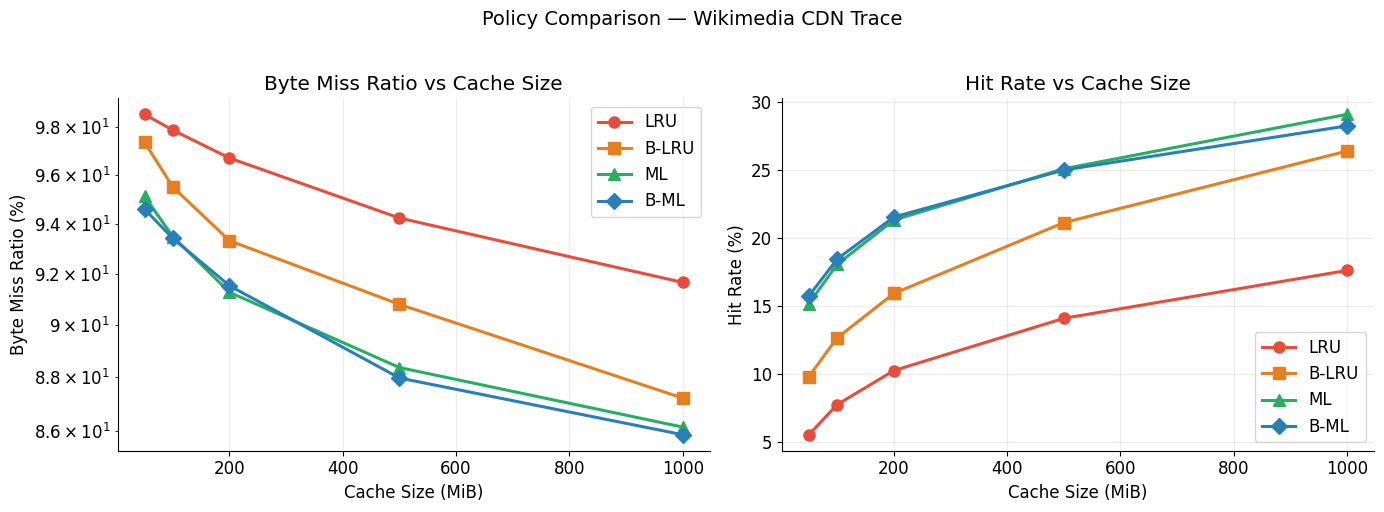

In [83]:
# ─── Plot 1: Byte Miss Ratio & Hit Rate vs Cache Size ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for p in POLICIES:
    xs   = [r['mib']  for r in sweep_results[p]]
    bmrs = [r['bmr']*100 for r in sweep_results[p]]
    hrs  = [r['hr']*100  for r in sweep_results[p]]
    ax1.plot(xs, bmrs, marker=MARKERS[p], color=COLORS[p], label=p)
    ax2.plot(xs, hrs,  marker=MARKERS[p], color=COLORS[p], label=p)

ax1.set(xlabel='Cache Size (MiB)', ylabel='Byte Miss Ratio (%)',
        title='Byte Miss Ratio vs Cache Size', yscale='log')
ax1.legend(); ax1.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax2.set(xlabel='Cache Size (MiB)', ylabel='Hit Rate (%)',
        title='Hit Rate vs Cache Size')
ax2.legend()

plt.suptitle('Policy Comparison — Wikimedia CDN Trace', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sweep_bmr_hitrate.png', dpi=150, bbox_inches='tight')
plt.show()

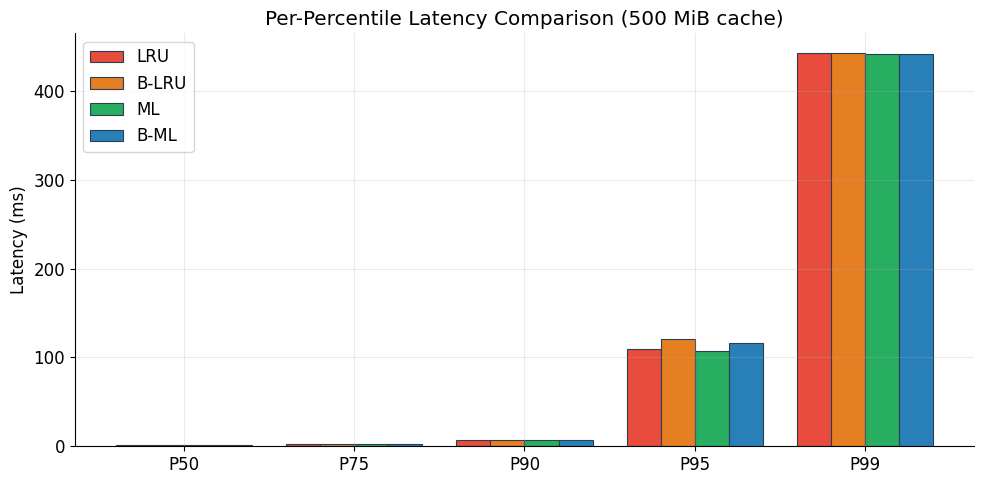

In [84]:
# ─── Plot 2: Per-Percentile Latency (at 500 MiB) ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

pcts = [50, 75, 90, 95, 99]
bar_w = 0.2
x = np.arange(len(pcts))

for i, (name, lat) in enumerate([("LRU",   lru_lat),
                                   ("B-LRU", blru_lat),
                                   ("ML",    ml_lat),
                                   ("B-ML",  bml_lat)]):
    vals = [np.percentile(lat, p) for p in pcts]
    bars = ax.bar(x + i*bar_w, vals, width=bar_w,
                  color=COLORS[name], label=name, edgecolor='#2c3e50', linewidth=0.8)

ax.set_xticks(x + bar_w*1.5)
ax.set_xticklabels([f'P{p}' for p in pcts])
ax.set(ylabel='Latency (ms)',
       title=f'Per-Percentile Latency Comparison ({EVAL_CAPACITY//(1024**2)} MiB cache)')
ax.legend()

plt.tight_layout()
plt.savefig('percentile_latency.png', dpi=150, bbox_inches='tight')
plt.show()

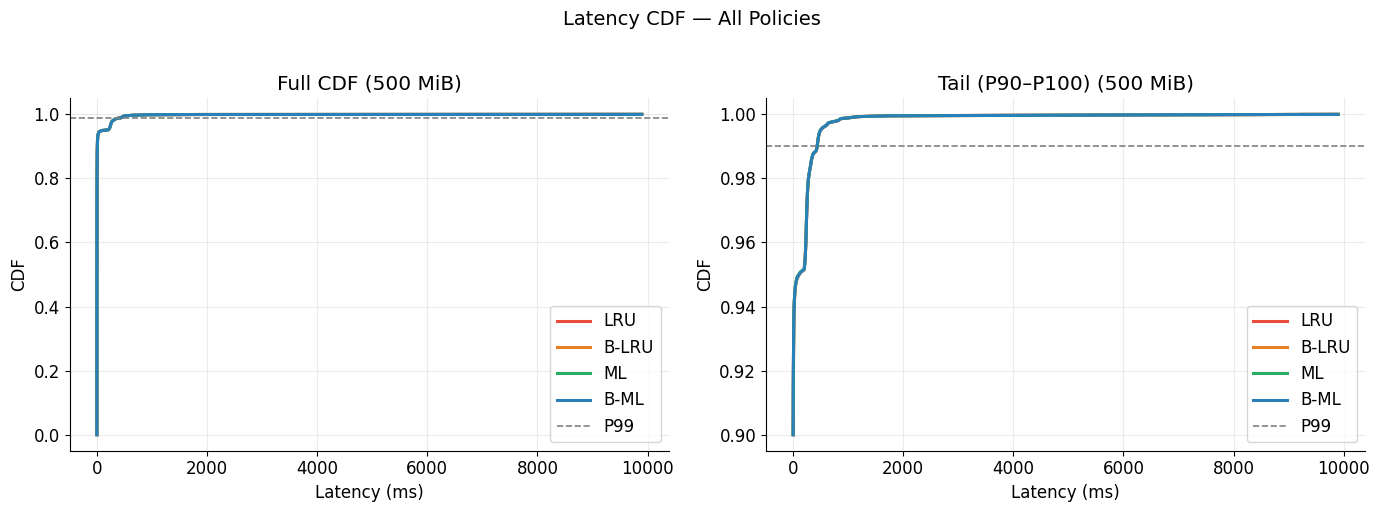

In [85]:
# ─── Plot 3: Full Latency CDF ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, zoom, title in zip(axes, [False, True], ['Full CDF', 'Tail (P90–P100)']):
    for name, lat in [("LRU",   lru_lat), ("B-LRU", blru_lat),
                       ("ML",    ml_lat),  ("B-ML",  bml_lat)]:
        sl   = np.sort(lat)
        cdf  = np.arange(1, len(sl)+1) / len(sl)
        if zoom:
            mask = cdf >= 0.90
            ax.plot(sl[mask], cdf[mask], color=COLORS[name], label=name)
        else:
            ax.plot(sl, cdf, color=COLORS[name], label=name)

    ax.axhline(0.99, color='gray', ls='--', lw=1.2, label='P99')
    ax.set(xlabel='Latency (ms)', ylabel='CDF', title=title +
           f' ({EVAL_CAPACITY//(1024**2)} MiB)')
    ax.legend()

plt.suptitle('Latency CDF — All Policies', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('latency_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

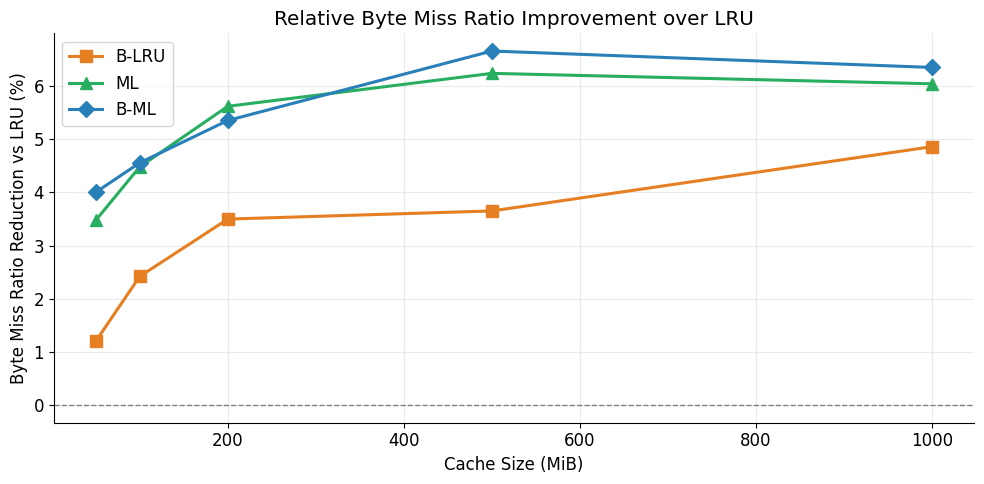

In [86]:
# ─── Plot 4: Byte Miss Ratio Improvement over LRU ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

szs = [r['mib'] for r in sweep_results['LRU']]
lru_bmrs = np.array([r['bmr'] for r in sweep_results['LRU']])

for name in ['B-LRU', 'ML', 'B-ML']:
    bmrs = np.array([r['bmr'] for r in sweep_results[name]])
    # reduction relative to LRU
    reduction = (lru_bmrs - bmrs) / lru_bmrs * 100
    ax.plot(szs, reduction, marker=MARKERS[name], color=COLORS[name], label=name)

ax.axhline(0, color='gray', ls='--', lw=1)
ax.set(xlabel='Cache Size (MiB)',
       ylabel='Byte Miss Ratio Reduction vs LRU (%)',
       title='Relative Byte Miss Ratio Improvement over LRU')
ax.legend()

plt.tight_layout()
plt.savefig('bmr_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

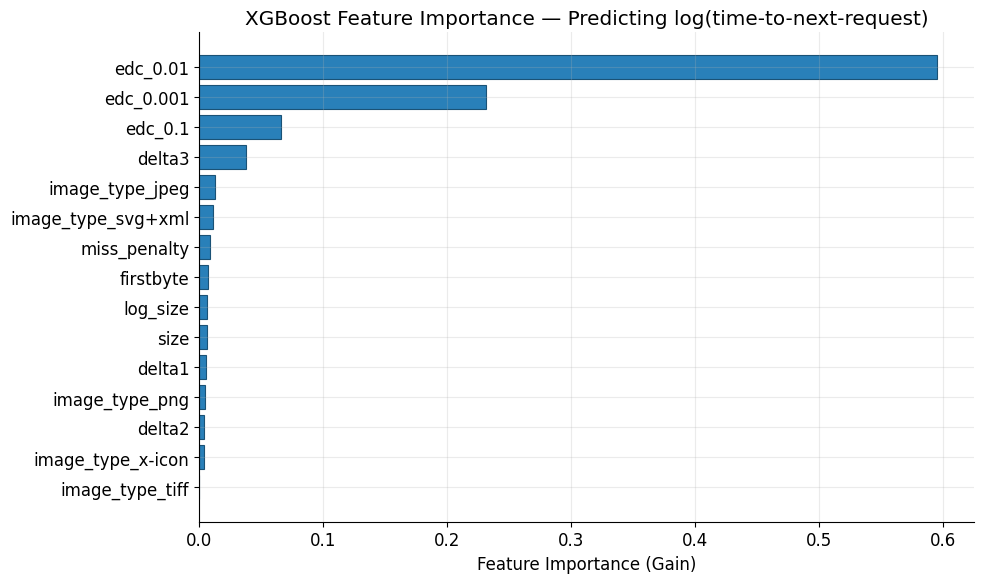

In [87]:
# ─── Plot 5: Feature Importance ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

fi = sorted(zip(features, model.feature_importances_), key=lambda x: x[1], reverse=True)[:15]
names, vals = zip(*fi)

bars = ax.barh(range(len(names)), vals[::-1],
               color='#2980b9', edgecolor='#1a5276', linewidth=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(list(names[::-1]))
ax.set(xlabel='Feature Importance (Gain)',
       title='XGBoost Feature Importance — Predicting log(time-to-next-request)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

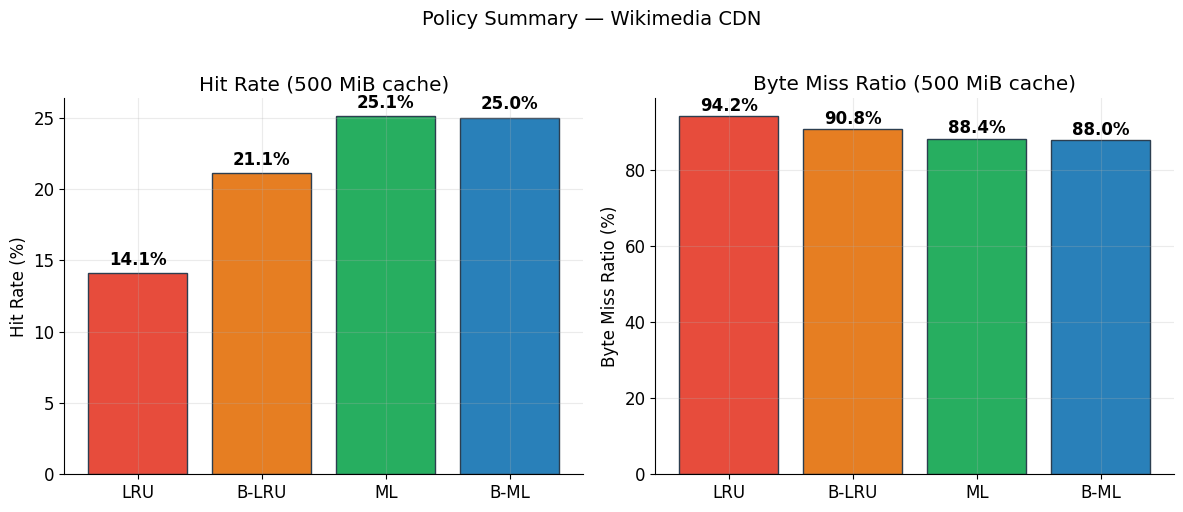

In [88]:
# ─── Plot 6: Summary bar — Byte Miss Ratio at eval capacity ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

pol_names = POLICIES
bmr_vals  = [r['bmr']*100 for r in [
    [d for d in sweep_results['LRU']   if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
    [d for d in sweep_results['B-LRU'] if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
    [d for d in sweep_results['ML']    if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
    [d for d in sweep_results['B-ML']  if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
]]
hr_vals = [r['hr']*100 for r in [
    [d for d in sweep_results['LRU']   if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
    [d for d in sweep_results['B-LRU'] if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
    [d for d in sweep_results['ML']    if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
    [d for d in sweep_results['B-ML']  if d['mib'] == EVAL_CAPACITY//(1024**2)][0],
]]

bar_colors = [COLORS[p] for p in POLICIES]

b1 = ax1.bar(pol_names, hr_vals, color=bar_colors, edgecolor='#2c3e50', linewidth=1)
for bar, v in zip(b1, hr_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.set(ylabel='Hit Rate (%)', title=f'Hit Rate ({EVAL_CAPACITY//(1024**2)} MiB cache)')

b2 = ax2.bar(pol_names, bmr_vals, color=bar_colors, edgecolor='#2c3e50', linewidth=1)
for bar, v in zip(b2, bmr_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set(ylabel='Byte Miss Ratio (%)', title=f'Byte Miss Ratio ({EVAL_CAPACITY//(1024**2)} MiB cache)')

plt.suptitle('Policy Summary — Wikimedia CDN', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('policy_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Online LRB Cache (Full Architecture)
---
Faithful implementation of the LRB paper's online training loop:
32 deltas, 10 EDCs, sliding memory window, retrains every 128K samples.

In [95]:
class OnlineLRBCache:
    """Online LRB: Latency-Aware Relaxed Belady with online XGBoost retraining.

    Architecture mirrors the LRB paper (NSDI'20):
    - Sliding memory window for labeling
    - 32 inter-access deltas, 10 EDCs
    - GBM retrained every 128K samples
    - Eviction: Max predicted time-to-next-request
    """
    EDC_ALPHAS = [2**(9+i) for i in range(10)]

    def __init__(self, capacity_bytes, window_size=128_000, batch_size=10_000, sample_rate=0.1, use_bloom=True):
        self.capacity   = capacity_bytes
        self.window     = window_size
        self.batch_size = batch_size
        self.sample_rate = sample_rate
        self.use_bloom  = use_bloom

        self.seen       = set()
        self.cache_d    = {}
        self.cache_l    = []
        self.cur_bytes  = 0

        self.mem_win    = deque()
        self.obj_meta   = {}   # hash -> (past_steps[], edcs[])

        self.unlabeled  = {}
        self.feat_buf   = []
        self.targ_buf   = []

        self.model      = None
        self.step       = 0
        self.hits       = 0
        self.misses     = 0
        self.latencies  = []
        self.byte_misses = 0
        self.total_bytes = 0

    def _feats(self, h, size, fb, update=True):
        if h not in self.obj_meta:
            deltas = [-1.0] * 32
            edcs   = [1.0]  * 10
            if update: self.obj_meta[h] = ([self.step], edcs[:])
            return [size, fb] + deltas + edcs

        steps, cur_edcs = self.obj_meta[h]
        d1 = self.step - steps[-1]
        deltas = [d1]
        for i in range(len(steps)-1, max(-1, len(steps)-32), -1):
            if i > 0: deltas.append(steps[i] - steps[i-1])
        deltas += [-1.0] * (32 - len(deltas))

        new_edcs = [1.0 + cur_edcs[i] * (0.5 ** (d1 / self.EDC_ALPHAS[i]))
                    for i in range(10)]

        if update:
            steps = (steps + [self.step])[-33:]
            self.obj_meta[h] = (steps, new_edcs)

        return [size, fb] + deltas + new_edcs

    def _evict(self, need):
        while self.cur_bytes + need > self.capacity and self.cache_l:
            cands = random.sample(self.cache_l, min(64, len(self.cache_l)))
            if self.model is None:
                ev = cands[0]
            else:
                cf = [self._feats(c, *self.cache_d[c][:2], update=False) for c in cands]
                ps = self.model.predict(xgb.DMatrix(np.array(cf)))
                ev = max(range(len(cands)), key=lambda i: ps[i])
                ev = cands[ev]
            idx   = self.cache_d[ev][2]
            last  = self.cache_l[-1]
            self.cache_l[idx] = last
            self.cache_d[last] = (*self.cache_d[last][:2], idx)
            self.cache_l.pop()
            self.cur_bytes -= self.cache_d[ev][0]
            del self.cache_d[ev]

    def request(self, h, size, fb):
        self.step += 1
        feats = self._feats(h, size, fb, update=True)

        # Label unlabeled sample if this is a repeat
        if h in self.unlabeled:
            rec_step, rec_feats = self.unlabeled.pop(h)
            self.feat_buf.append(rec_feats)
            self.targ_buf.append(np.log1p(self.step - rec_step))

        # Randomly sample for training
        if random.random() < self.sample_rate:
            self.unlabeled[h] = (self.step, feats)

        self.mem_win.append(h)
        # Expire old samples from window
        while len(self.mem_win) > self.window:
            old = self.mem_win.popleft()
            if old in self.unlabeled:
                _, rf = self.unlabeled.pop(old)
                self.feat_buf.append(rf)
                self.targ_buf.append(np.log1p(self.window * 2))

        # Retrain
        if len(self.feat_buf) >= self.batch_size:
            X = np.array(self.feat_buf[:self.batch_size])
            y = np.array(self.targ_buf[:self.batch_size])
            self.model = xgb.train(
                {'objective': 'reg:squarederror', 'max_depth': 6,
                 'learning_rate': 0.1, 'tree_method': 'hist'},
                xgb.DMatrix(X, label=y), num_boost_round=50
            )
            self.feat_buf = self.feat_buf[self.batch_size:]
            self.targ_buf = self.targ_buf[self.batch_size:]

        penalty = compute_miss_penalty(size, fb)
        self.total_bytes += size

        if size > self.capacity:
            self.misses += 1; self.byte_misses += size
            self.latencies.append(penalty)
            if self.use_bloom: self.seen.add(h)
            return

        if h in self.cache_d:
            self.hits += 1; self.latencies.append(0)
        else:
            self.misses += 1; self.byte_misses += size
            self.latencies.append(penalty)
            
            # Bloom filter gate
            if self.use_bloom and h not in self.seen:
                self.seen.add(h)
                return
            if self.use_bloom:
                self.seen.add(h)

            self._evict(size)
            self.cache_l.append(h)
            self.cache_d[h] = (size, fb, len(self.cache_l)-1)
            self.cur_bytes += size

    def metrics(self):
        tot = self.hits + self.misses
        lat = np.array(self.latencies)
        return {
            'hit_rate':       self.hits / tot if tot else 0,
            'byte_miss_ratio': self.byte_misses / self.total_bytes if self.total_bytes else 0,
            'p50':  np.percentile(lat, 50) if len(lat) else 0,
            'p90':  np.percentile(lat, 90) if len(lat) else 0,
            'p99':  np.percentile(lat, 99) if len(lat) else 0,
            'model_trained': self.model is not None,
        }

## OnlineLRBCache Demo
Evaluating `OnlineLRBCache` streaming performance on the next 500K contiguous rows.

In [ ]:
print("\\n" + "="*50)
print("ONLINE LEARNING CACHE EVALUATION")
print("Streaming the next 500,000 rows (500,000 to 1,000,000)...")
print("="*50)

# Load the next contiguous chunk of the dataset
CHUNK_2_START = 500_000
CHUNK_2_SIZE  = 500_000
df_online = load_contiguous_chunk(path, CHUNK_2_SIZE, skip_rows=CHUNK_2_START)

print(f"Loaded {len(df_online)} rows for continuous online learning.\\n")

# Initialize the stateful Online LRB Cache
# 500 MiB capacity to match offline tests
online_cache = OnlineLRBCache(capacity_bytes=500 * 1024 * 1024, use_bloom=True)

# We use tqdm to show progress since this takes a while (online tree building)
# We use tqdm to show progress since this takes a while (online tree building)
for row in tqdm(df_online.itertuples(name=None), total=len(df_online), desc="Online LRB"):
    # row is (Index, timestamp, hash, type, size, firstbyte)
    _, ts, h, itype, size, fb = row
    online_cache.request(h, size, fb)

om = online_cache.metrics()

print("\\nRunning Baselines on the new chunk...")
lru_hr, lru_lat, lru_bm, lru_tb = simulate_lru(df_online, 500 * 1024 * 1024)
blru_hr, blru_lat, blru_bm, blru_tb = simulate_blru(df_online, 500 * 1024 * 1024)



\n==================================================
ONLINE LEARNING CACHE EVALUATION
Streaming the next 500,000 rows (500,000 to 1,000,000)...


Loading:   0%|          | 0/1000000 [00:00<?, ?it/s]

Loaded 500000 rows for continuous online learning.\n


Online LRB:   0%|          | 0/500000 [00:00<?, ?it/s]

\nRunning Baselines on the new chunk...
\n───────────────────────────────────────────────────────
  Online LRB Cache Final Metrics
───────────────────────────────────────────────────────
  Total Requests Processed: 500,000
  Hit Rate        :  19.22%
  Byte Miss Ratio :  89.35%
  P50 Latency     :     1.11 ms
  P90 Latency     :     7.37 ms
  P99 Latency     :   431.81 ms
\n───────────────────────────────────────────────────────
  LRU Baseline Metrics (Chunk 2)
───────────────────────────────────────────────────────
  Hit Rate        :  13.11%
  Byte Miss Ratio :  91.50%
  P50 Latency     :     1.16 ms
  P90 Latency     :     7.53 ms
  P99 Latency     :   431.31 ms


In [102]:
print("\\n" + "─"*55)
print("  LRU Baseline Metrics (Chunk 2)")
print("─"*55)
print(f"  Hit Rate        :  {lru_hr*100:.2f}%")
print(f"  Byte Miss Ratio :  {lru_bm/lru_tb*100:.2f}%")
print(f"  P50 Latency     : {np.percentile(lru_lat, 50):8.2f} ms")
print(f"  P90 Latency     : {np.percentile(lru_lat, 90):8.2f} ms")
print(f"  P99 Latency     : {np.percentile(lru_lat, 99):8.2f} ms")

print("\n" + "─"*55)
print("  B-LRU Baseline Metrics (Chunk 2)")
print("─"*55)
print(f"  Hit Rate        :  {blru_hr*100:.2f}%")
print(f"  Byte Miss Ratio :  {blru_bm/blru_tb*100:.2f}%")
print(f"  P50 Latency     : {np.percentile(blru_lat, 50):8.2f} ms")
print(f"  P90 Latency     : {np.percentile(blru_lat, 90):8.2f} ms")
print(f"  P99 Latency     : {np.percentile(blru_lat, 99):8.2f} ms")
print("─"*55 + "\n")


print("\\n" + "─"*55)
print("  Online LRB Cache Final Metrics")
print("─"*55)
print(f"  Total Requests Processed: {online_cache.step:,}")
print(f"  Hit Rate        :  {om['hit_rate']*100:.2f}%")
print(f"  Byte Miss Ratio :  {om['byte_miss_ratio']*100:.2f}%")
print(f"  P50 Latency     : {om['p50']:8.2f} ms")
print(f"  P90 Latency     : {om['p90']:8.2f} ms")
print(f"  P99 Latency     : {om['p99']:8.2f} ms")


\n───────────────────────────────────────────────────────
  LRU Baseline Metrics (Chunk 2)
───────────────────────────────────────────────────────
  Hit Rate        :  13.11%
  Byte Miss Ratio :  91.50%
  P50 Latency     :     1.16 ms
  P90 Latency     :     7.53 ms
  P99 Latency     :   431.31 ms

───────────────────────────────────────────────────────
  B-LRU Baseline Metrics (Chunk 2)
───────────────────────────────────────────────────────
  Hit Rate        :  19.10%
  Byte Miss Ratio :  89.11%
  P50 Latency     :     1.11 ms
  P90 Latency     :     7.37 ms
  P99 Latency     :   431.72 ms
───────────────────────────────────────────────────────

\n───────────────────────────────────────────────────────
  Online LRB Cache Final Metrics
───────────────────────────────────────────────────────
  Total Requests Processed: 500,000
  Hit Rate        :  19.22%
  Byte Miss Ratio :  89.35%
  P50 Latency     :     1.11 ms
  P90 Latency     :     7.37 ms
  P99 Latency     :   431.81 ms


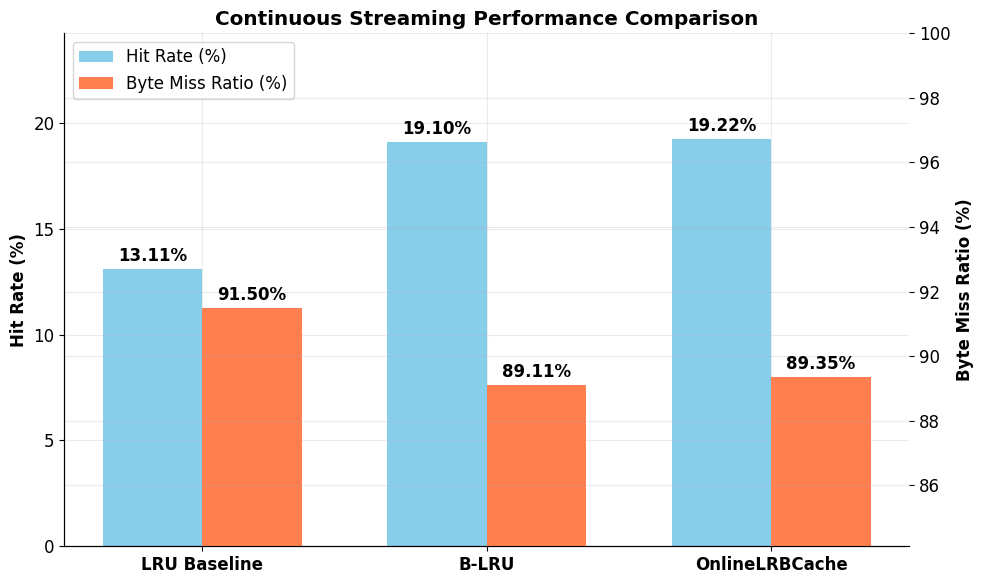

In [103]:
labels = ['LRU Baseline', 'B-LRU', 'OnlineLRBCache']
hit_rates = [lru_hr * 100, blru_hr * 100, om['hit_rate'] * 100]
byte_miss_ratios = [lru_bm / lru_tb * 100, blru_bm / blru_tb * 100, om['byte_miss_ratio'] * 100]
x = np.arange(len(labels))
width = 0.35
fig, ax1 = plt.subplots(figsize=(10, 6))
rects1 = ax1.bar(x - width/2, hit_rates, width, label='Hit Rate (%)', color='skyblue')
ax1.set_ylabel('Hit Rate (%)', fontweight='bold')
ax1.set_ylim(0, max(hit_rates) + 5)
ax1.set_title('Continuous Streaming Performance Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, byte_miss_ratios, width, label='Byte Miss Ratio (%)', color='coral')
ax2.set_ylabel('Byte Miss Ratio (%)', fontweight='bold')
ax2.set_ylim(min(byte_miss_ratios) - 5, 100)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
autolabel(rects1, ax1)
autolabel(rects2, ax2)
fig.tight_layout()
plt.show()


## Summary
---

| Policy | Key idea |
|--------|----------|
| **LRU** | Evict least recently used — simple baseline |
| **B-LRU** | LRU + Bloom filter admission — blocks one-hit-wonders |
| **ML** | XGBoost predicts reuse distance; evicts low-penalty + far-reuse objects |
| **B-ML** | ML eviction + Bloom filter admission |
| **Online LRB** | Full paper architecture: 32δ + 10 EDC features, 128K online retraining |

**Key metrics reported**: Hit Rate, Byte Miss Ratio, P50/P75/P90/P95/P99 latency